# Anharmonic Oscillator: NN Thimble — Lambda Scan (Start = 0, Finish = 0)

This notebook trains a fresh **nonlinear thimble** model
$x = A^\top z + b + g_\theta(z)$
for each $\lambda$ in a configurable list, with **both endpoints pinned at zero**.

For every $\lambda$ it runs **3 different random seeds**, records all results,
and selects the **best seed** (lowest final variance loss).

For every $\lambda$ × seed it records:
- **ML propagator** $K(0,T;0,0)$ with MC std error
- **Basis truncation** independent verification
- **Mehler kernel** (exact, for $\lambda=0$ sanity)
- Loss history, ESS/N
- Arrow (before/after) diagrams

All results go to a single CSV, with a `best` flag marking the winning seed.
A final comparison plot shows ML (best seed) vs basis truncation across $\lambda$.

In [1]:
import torch, torch.nn as nn, numpy as np, time, csv, os, math
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)

## 1. Parameters

Endpoints are fixed at $(0, 0)$.  Change `lambda_list` to control the scan.
Bias-initialisation code for non-zero endpoints is kept but dormant.

In [2]:
N       = 16
T       = 1.0
m       = 1.0
omega   = 2.0
epsilon = 0.01
D       = N - 1
rank    = 8
epochs  = 15000 
batch   = 2048
N_mc    = 100_000

# ── endpoints (fixed at zero for this notebook) ──
x_i_prop = 0.0
x_f_prop = 0.0
 
lambda_list = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 2, 3, 4,  8]

print(f"N={N}, T={T}, m={m}, omega={omega}, eps={epsilon}")
print(f"D={D}, rank={rank}, epochs={epochs}, batch={batch}")
print(f"Endpoints: x_i={x_i_prop}, x_f={x_f_prop}")
print(f"Lambda values to scan: {lambda_list}")

N=16, T=1.0, m=1.0, omega=2.0, eps=0.01
D=15, rank=8, epochs=15000, batch=2048
Endpoints: x_i=0.0, x_f=0.0
Lambda values to scan: [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 2, 3, 4, 8]


## 2. Action Function

Parameterised for general endpoints (kept for future use).
Currently called with $(0, 0)$.

In [3]:
def complex_action(x, x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val):
    bsz = x.shape[0]
    pad_i = torch.full((bsz, 1), x_i, dtype=torch.complex64)
    pad_f = torch.full((bsz, 1), x_f, dtype=torch.complex64)
    x_pad = torch.cat([pad_i, x, pad_f], dim=1)
    dx = x_pad[:, 1:] - x_pad[:, :-1]
    kinetic = (m_val / (2 * a_dt)) * torch.sum(dx**2, dim=1)
    omega_sq = omega_val**2 - 1j * eps_val
    pot_harm = (a_dt * m_val / 2) * omega_sq * torch.sum(x**2, dim=1)
    pot_quartic = a_dt * (lam_val / 4) * torch.sum(x**4, dim=1)
    return kinetic - pot_harm - pot_quartic

## 3. Nonlinear Thimble Model

`ThimbleFlowNL` — linear map $A^\top z + b$ plus rank-$r$ bottleneck NN
correction.  Jacobian via matrix-determinant lemma.

`b_init` parameter kept for non-zero endpoint use later.

In [4]:
class ThimbleFlowNL(nn.Module):
    def __init__(self, dim, rank=8, b_init=None):
        super().__init__()
        self.dim = dim
        self.rank = rank

        self.A_real = nn.Parameter(torch.eye(dim) + 0.01 * torch.randn(dim, dim))
        self.A_imag = nn.Parameter(0.01 * torch.randn(dim, dim))

        # bias init: linear interpolation for general endpoints, zeros for (0,0)
        if b_init is not None:
            self.b_real = nn.Parameter(b_init.clone().float())
        else:
            self.b_real = nn.Parameter(torch.zeros(dim))
        self.b_imag = nn.Parameter(torch.zeros(dim))

        r = rank
        self.W1 = nn.Parameter(torch.randn(r, dim) * (2.0 / dim)**0.5)
        self.b1 = nn.Parameter(torch.zeros(r))
        self.W2 = nn.Parameter(torch.randn(r, r) * (2.0 / r)**0.5)
        self.b2 = nn.Parameter(torch.zeros(r))
        self.W3 = nn.Parameter(torch.randn(2 * dim, r) * 0.001)
        self.b3 = nn.Parameter(torch.zeros(2 * dim))

    def _get_A(self):
        return self.A_real + 1j * self.A_imag

    def forward(self, z):
        A = self._get_A()
        b = self.b_real + 1j * self.b_imag
        x = z.to(torch.complex64) @ A.t() + b
        h1 = z @ self.W1.t() + self.b1
        a1 = torch.tanh(h1)
        h2 = a1 @ self.W2.t() + self.b2
        a2 = torch.tanh(h2)
        out = a2 @ self.W3.t() + self.b3
        g = out[:, :self.dim].to(torch.complex64) + 1j * out[:, self.dim:].to(torch.complex64)
        return x + g, a1, a2

    def compute_log_det_J(self, z, a1, a2, detach_correction=False):
        A = self._get_A()
        sign_A, logabs_A = torch.linalg.slogdet(A)
        log_det_A = logabs_A + 1j * torch.angle(sign_A)

        C = self.W3[:self.dim].to(torch.complex64) + 1j * self.W3[self.dim:].to(torch.complex64)
        A_invT_C = torch.linalg.solve(A.t(), C)
        K_mat = self.W1.to(torch.complex64) @ A_invT_C

        batch = z.shape[0]
        r = self.rank
        _a1 = a1.detach() if detach_correction else a1
        _a2 = a2.detach() if detach_correction else a2

        da1 = (1.0 - _a1**2).to(torch.complex64)
        M1 = da1.unsqueeze(-1) * K_mat.unsqueeze(0)
        W2c = self.W2.to(torch.complex64)
        if detach_correction:
            W2c = W2c.detach()
        M2 = torch.bmm(W2c.unsqueeze(0).expand(batch, -1, -1), M1)
        da2 = (1.0 - _a2**2).to(torch.complex64)
        M3 = da2.unsqueeze(-1) * M2
        I_r = torch.eye(r, dtype=torch.complex64).unsqueeze(0)
        sign_c, logabs_c = torch.linalg.slogdet(I_r + M3)
        log_det_correction = logabs_c + 1j * torch.angle(sign_c)
        if detach_correction:
            log_det_correction = log_det_correction.detach()
        return log_det_A + log_det_correction

## 4. Training & Estimation Function

`run_single()` trains a fresh model for one $\lambda$ and returns:
- propagator $K$, std error, loss history, ESS
- the trained model (for arrow plots)
- 200 before/after arrow samples

In [5]:
def run_single(lam_val, x_i=0.0, x_f=0.0,
               N_val=16, T_val=1.0, m_val=1.0, omega_val=2.0, eps_val=0.01,
               rank_val=8, epochs_val=15000, batch_val=2048, N_mc_val=100_000,
               seed=42, verbose=True):

    torch.manual_seed(seed)
    np.random.seed(seed)

    D_val = N_val - 1
    a_dt = T_val / N_val

    # bias init for general endpoints (zeros when x_i == x_f == 0)
    b_init = torch.linspace(float(x_i), float(x_f), D_val + 2)[1:-1]
    model = ThimbleFlowNL(D_val, rank=rank_val, b_init=b_init)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs_val, eta_min=1e-4)

    loss_history = []
    t0 = time.time()

    for epoch in range(epochs_val):
        optimizer.zero_grad()
        z = torch.randn(batch_val, D_val)
        x, a1, a2 = model(z)
        S = complex_action(x, x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val)
        log_P = -0.5 * torch.sum(z**2, dim=1) - (D_val / 2) * np.log(2 * np.pi)
        log_det_J = model.compute_log_det_J(z, a1, a2, detach_correction=True)
        log_W = 1j * S + log_det_J - log_P.to(torch.complex64)
        loss = torch.var(log_W.real) + torch.var(log_W.imag)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()
        loss_history.append(loss.item())
        if verbose and ((epoch + 1) % 3000 == 0 or epoch == 0):
            print(f"    Epoch {epoch+1:5d}/{epochs_val} | loss = {loss.item():.6e} | "
                  f"{time.time()-t0:.0f}s", flush=True)

    elapsed = time.time() - t0

    norm_factor = (m_val / (2 * np.pi * 1j * a_dt)) ** (N_val / 2)
    with torch.no_grad():
        z_mc = torch.randn(N_mc_val, D_val)
        x_mc, a1_mc, a2_mc = model(z_mc)
        S_mc = complex_action(x_mc, x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val)
        log_P_mc = -0.5 * torch.sum(z_mc**2, dim=1) - (D_val / 2) * np.log(2 * np.pi)
        log_det_mc = model.compute_log_det_J(z_mc, a1_mc, a2_mc)
        log_W_mc = 1j * S_mc + log_det_mc - log_P_mc.to(torch.complex64)
        log_W_max = torch.max(log_W_mc.real)
        W_shifted = torch.exp(log_W_mc - log_W_max)
        K_mc = norm_factor * torch.exp(log_W_max).item() * torch.mean(W_shifted).numpy()
        W_for_err = norm_factor * torch.exp(log_W_max).item() * W_shifted.numpy()
        K_std = np.std(W_for_err) / np.sqrt(N_mc_val)
        W_ess = torch.exp(log_W_mc[:10000] - torch.max(log_W_mc[:10000].real)).numpy()
        ess = float(np.abs(np.mean(W_ess))**2 / np.mean(np.abs(W_ess)**2))

    # ── arrow data (200 samples) ──
    n_arrows = 200
    with torch.no_grad():
        z_arr = torch.randn(n_arrows, D_val)
        S_before = complex_action(z_arr.to(torch.complex64),
                                  x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val)
        W_before = torch.exp(1j * S_before).numpy()
        W_before_norm = W_before / np.max(np.abs(W_before))

        x_arr, a1_arr, a2_arr = model(z_arr)
        S_after = complex_action(x_arr, x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val)
        log_P_arr = -0.5 * torch.sum(z_arr**2, dim=1) - (D_val / 2) * np.log(2 * np.pi)
        log_det_arr = model.compute_log_det_J(z_arr, a1_arr, a2_arr)
        log_W_arr = 1j * S_after + log_det_arr - log_P_arr.to(torch.complex64)
        W_after = torch.exp(log_W_arr - torch.max(log_W_arr.real)).numpy()
        W_after_norm = W_after / np.max(np.abs(W_after))

    result = dict(
        lam=lam_val, x_i=x_i, x_f=x_f, seed=seed,
        N=N_val, T=T_val, m=m_val,
        omega=omega_val, eps=eps_val, rank=rank_val, epochs=epochs_val,
        K_re=float(K_mc.real), K_im=float(K_mc.imag), abs_K=float(abs(K_mc)),
        std_err=float(K_std), final_loss=loss_history[-1], ess_n=ess,
        time_s=elapsed, loss_history=loss_history,
        W_before_norm=W_before_norm, W_after_norm=W_after_norm,
    )
    if verbose:
        print(f"  => K = {K_mc:.10f}  |K| = {abs(K_mc):.8f}  "
              f"loss = {loss_history[-1]:.2e}  ESS/N = {ess:.4f}  ({elapsed:.0f}s)",
              flush=True)
    return result

## 5. Exact & Independent Solutions

- **Mehler kernel** — exact HO propagator for any endpoints
- **Free-particle kernel** — exact with $\omega=0$, $\lambda=0$
- **Basis truncation** — independent numerical verification

In [6]:
def mehler_kernel(x_i, x_f, T_val, m_val, omega_val):
    sinwT = np.sin(omega_val * T_val)
    coswT = np.cos(omega_val * T_val)
    prefactor = np.sqrt(m_val * omega_val / (2 * np.pi * 1j * sinwT))
    exponent = (1j * m_val * omega_val / (2 * sinwT)) * (
        (x_i**2 + x_f**2) * coswT - 2 * x_i * x_f)
    return prefactor * np.exp(exponent)

def free_particle_kernel(x_i, x_f, T_val, m_val):
    return np.sqrt(m_val / (2 * np.pi * 1j * T_val)) * np.exp(
        1j * m_val * (x_f - x_i)**2 / (2 * T_val))

# ── Basis truncation (independent numerical verification) ──
N_basis = 400
alpha_x = 1.0 / np.sqrt(2 * m * omega)

def _psi_n_HO(n, x):
    xi = np.sqrt(m * omega) * x
    gauss_pref = (m * omega / np.pi)**0.25 * np.exp(-0.5 * xi**2)
    if n == 0:
        return gauss_pref
    psi_prev = 1.0
    psi_curr = np.sqrt(2) * xi
    if n == 1:
        return gauss_pref * psi_curr
    for k in range(1, n):
        psi_next = (np.sqrt(2)*xi*psi_curr - np.sqrt(k)*psi_prev) / np.sqrt(k+1)
        psi_prev = psi_curr
        psi_curr = psi_next
    return gauss_pref * psi_curr

def _x4_HO_matrix(Nb):
    x2 = np.zeros((Nb, Nb))
    for nn in range(Nb):
        x2[nn, nn] = alpha_x**2 * (2*nn + 1)
        if nn + 2 < Nb:
            val = alpha_x**2 * np.sqrt((nn+1)*(nn+2))
            x2[nn, nn+2] = val
            x2[nn+2, nn] = val
    return x2 @ x2

def compute_K_basis_truncation(xi, xf, lam_val, T_val, Nb=400):
    E_HO = np.array([omega * (n + 0.5) for n in range(Nb)])
    phi_xi = np.array([_psi_n_HO(n, xi) for n in range(Nb)])
    phi_xf = np.array([_psi_n_HO(n, xf) for n in range(Nb)])
    x4_mat = _x4_HO_matrix(Nb)
    H = np.diag(E_HO) + (lam_val / 4.0) * x4_mat
    E_vals, U = np.linalg.eigh(H)
    psi_xi_eig = U.T @ phi_xi
    psi_xf_eig = U.T @ phi_xf
    weights = psi_xf_eig * psi_xi_eig
    etas = np.array([0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15])
    K_eta = np.array([np.sum(weights * np.exp(-E_vals * (eta + 1j*T_val)))
                      for eta in etas])
    cr4 = np.polyfit(etas, K_eta.real, 4)
    ci4 = np.polyfit(etas, K_eta.imag, 4)
    K4 = np.polyval(cr4, 0) + 1j * np.polyval(ci4, 0)
    cr3 = np.polyfit(etas, K_eta.real, 3)
    ci3 = np.polyfit(etas, K_eta.imag, 3)
    K3 = np.polyval(cr3, 0) + 1j * np.polyval(ci3, 0)
    return K4, abs(K4 - K3)

K_mehler_00 = mehler_kernel(0, 0, T, m, omega)
print(f"Mehler K(0,T;0,0) = {K_mehler_00:.10f}")
print(f"Free particle K(0,T;0,0) = {free_particle_kernel(0, 0, T, m):.10f}")

Mehler K(0,T;0,0) = 0.4183666762-0.4183666762j
Free particle K(0,T;0,0) = 0.2820947918-0.2820947918j


## 6. Lambda Scan

For each $\lambda$, trains a fresh NN model, computes the ML propagator,
then runs basis truncation independently.  All stored in `scan_results`.

In [7]:
seed_list = [42, 45, 99]
all_results = []      # every run (3 per lambda)
best_results = []     # one per lambda (lowest final_loss)

print("=" * 80)
print("LAMBDA SCAN — NN Thimble + Basis Truncation  (x_i=0, x_f=0)")
print(f"  Lambdas: {lambda_list}")
print(f"  Seeds per lambda: {seed_list}")
print("=" * 80)

for i, lam_val in enumerate(lambda_list):
    print(f"\n{'='*80}")
    print(f"[{i+1}/{len(lambda_list)}] lam = {lam_val}")
    print(f"{'='*80}", flush=True)

    # ── Basis truncation (independent, computed once per lambda) ──
    K_basis, K_basis_unc = compute_K_basis_truncation(
        x_i_prop, x_f_prop, lam_val, T, N_basis)
    K_meh = mehler_kernel(x_i_prop, x_f_prop, T, m, omega)

    seed_runs = []
    for s_idx, seed_val in enumerate(seed_list):
        print(f"\n  --- Seed {seed_val} ({s_idx+1}/{len(seed_list)}) ---", flush=True)

        res = run_single(lam_val, x_i=x_i_prop, x_f=x_f_prop,
                         N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                         rank_val=rank, epochs_val=epochs, batch_val=batch,
                         N_mc_val=N_mc, seed=seed_val)

        res['K_basis_re'] = float(K_basis.real)
        res['K_basis_im'] = float(K_basis.imag)
        res['abs_K_basis'] = float(abs(K_basis))
        res['K_basis_unc'] = float(K_basis_unc)
        res['K_mehler_re'] = float(K_meh.real)
        res['K_mehler_im'] = float(K_meh.imag)

        K_ml = res['K_re'] + 1j * res['K_im']
        rel_diff = abs(K_ml - K_basis) / max(abs(K_basis), 1e-30)
        res['rel_diff_ml_basis'] = float(rel_diff)

        seed_runs.append(res)
        all_results.append(res)

    # ── Pick best seed (lowest final_loss) ──
    best = min(seed_runs, key=lambda r: r['final_loss'])
    best['is_best'] = True
    for r in seed_runs:
        if r is not best:
            r['is_best'] = False
    best_results.append(best)

    # ── Summary table for this lambda ──
    print(f"\n  Basis truncation: {K_basis:.10f}  (unc={K_basis_unc:.2e})")
    print(f"\n  {'Seed':>6s}  {'K_ML':>30s}  {'|K|':>10s}  {'loss':>10s}  {'ESS':>6s}  {'rel_diff':>9s}  Best?")
    print(f"  {'-'*90}")
    for r in seed_runs:
        kml = f"{r['K_re']:+.8f}{r['K_im']:+.8f}j"
        tag = " <<<" if r.get('is_best') else ""
        print(f"  {r['seed']:6d}  {kml:>30s}  {r['abs_K']:10.6f}  "
              f"{r['final_loss']:10.2e}  {r['ess_n']:6.4f}  {r['rel_diff_ml_basis']:9.2e}{tag}")

# keep scan_results pointing to best for downstream cells
scan_results = best_results

LAMBDA SCAN — NN Thimble + Basis Truncation  (x_i=0, x_f=0)
  Lambdas: [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 2, 3, 4, 8]
  Seeds per lambda: [42, 45, 99]

[1/18] lam = 0.0

  --- Seed 42 (1/3) ---


c:\Users\tomqu\Documents\MLandPython\envs\helios_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    Epoch     1/15000 | loss = 1.165789e+04 | 0s
    Epoch  3000/15000 | loss = 2.625976e-02 | 79s
    Epoch  6000/15000 | loss = 7.589663e-03 | 157s
    Epoch  9000/15000 | loss = 5.229548e-04 | 233s
    Epoch 12000/15000 | loss = 2.430267e-10 | 309s
    Epoch 15000/15000 | loss = 4.018804e-12 | 386s
  => K = 0.4177583530-0.4184572818j  |K| = 0.59129395  loss = 4.02e-12  ESS/N = 1.0000  (386s)

  --- Seed 45 (2/3) ---
    Epoch     1/15000 | loss = 1.101836e+04 | 0s
    Epoch  3000/15000 | loss = 1.455838e-02 | 77s
    Epoch  6000/15000 | loss = 1.160366e-02 | 154s
    Epoch  9000/15000 | loss = 1.890893e-04 | 231s
    Epoch 12000/15000 | loss = 1.173260e-05 | 307s
    Epoch 15000/15000 | loss = 5.714222e-12 | 384s
  => K = -0.4178536823+0.4186157575j  |K| = 0.59147346  loss = 5.71e-12  ESS/N = 1.0000  (384s)

  --- Seed 99 (3/3) ---
    Epoch     1/15000 | loss = 1.178127e+04 | 0s
    Epoch  3000/15000 | loss = 1.770349e-03 | 79s
    Epoch  6000/15000 | loss = 4.034827e-03 | 155s
   

### Save scan results to CSV

In [8]:
csv_path = "nn_loop_startfinish0.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["lam","x_i","x_f","seed","best",
                "K_ml_re","K_ml_im","abs_K_ml","std_err",
                "final_loss","ess_n",
                "K_basis_re","K_basis_im","abs_K_basis","K_basis_unc",
                "rel_diff_ml_basis",
                "K_mehler_re","K_mehler_im",
                "N","T","m","omega","eps","rank","epochs","time_s"])
    for r in all_results:
        w.writerow([
            f"{r['lam']:.6g}", f"{r['x_i']:.4g}", f"{r['x_f']:.4g}",
            r['seed'], "Y" if r.get('is_best') else "N",
            f"{r['K_re']:.16e}", f"{r['K_im']:.16e}", f"{r['abs_K']:.16e}",
            f"{r['std_err']:.6e}", f"{r['final_loss']:.6e}", f"{r['ess_n']:.6f}",
            f"{r['K_basis_re']:.16e}", f"{r['K_basis_im']:.16e}",
            f"{r['abs_K_basis']:.16e}", f"{r['K_basis_unc']:.6e}",
            f"{r['rel_diff_ml_basis']:.6e}",
            f"{r['K_mehler_re']:.16e}", f"{r['K_mehler_im']:.16e}",
            r['N'], r['T'], r['m'], r['omega'], r['eps'], r['rank'],
            r['epochs'], f"{r['time_s']:.1f}"])

print(f"Saved {len(all_results)} rows ({len(best_results)} lambdas × {len(seed_list)} seeds) to {csv_path}")
print()
hdr = f"{'lam':>5s}  {'seed':>6s}  {'best':>4s}  {'K_ML':>30s}  {'K_basis':>30s}  {'rel_diff':>9s}  {'loss':>9s}  {'ESS':>6s}"
print(hdr)
print("-" * len(hdr))
for r in all_results:
    kml = f"{r['K_re']:+.8f}{r['K_im']:+.8f}j"
    kba = f"{r['K_basis_re']:+.8f}{r['K_basis_im']:+.8f}j"
    tag = " <<<" if r.get('is_best') else ""
    print(f"{r['lam']:5.2f}  {r['seed']:6d}  {'Y' if r.get('is_best') else 'N':>4s}  "
          f"{kml:>30s}  {kba:>30s}  {r['rel_diff_ml_basis']:9.2e}  "
          f"{r['final_loss']:9.2e}  {r['ess_n']:6.4f}{tag}")

Saved 54 rows (18 lambdas × 3 seeds) to nn_loop_startfinish0.csv

  lam    seed  best                            K_ML                         K_basis   rel_diff       loss     ESS
-----------------------------------------------------------------------------------------------------------------
 0.00      42     Y         +0.41775835-0.41845728j         +0.41836404-0.41836687j   1.04e-03   4.02e-12  1.0000 <<<
 0.00      45     N         -0.41785368+0.41861576j         +0.41836404-0.41836687j   2.00e+00   5.71e-12  1.0000
 0.00      99     N         -0.41760495+0.41855327j         +0.41836404-0.41836687j   2.00e+00   5.07e-12  1.0000
 0.05      42     N         -0.42117703+0.41615945j         +0.41947603-0.41722096j   2.00e+00   1.30e-05  1.0000
 0.05      45     N         -0.41907587+0.41734586j         +0.41947603-0.41722096j   2.00e+00   1.30e-05  1.0000
 0.05      99     Y         +0.41963682-0.41692311j         +0.41947603-0.41722096j   5.72e-04   1.27e-05  1.0000 <<<
 0.10      42 

### Loss curves (6 per page)

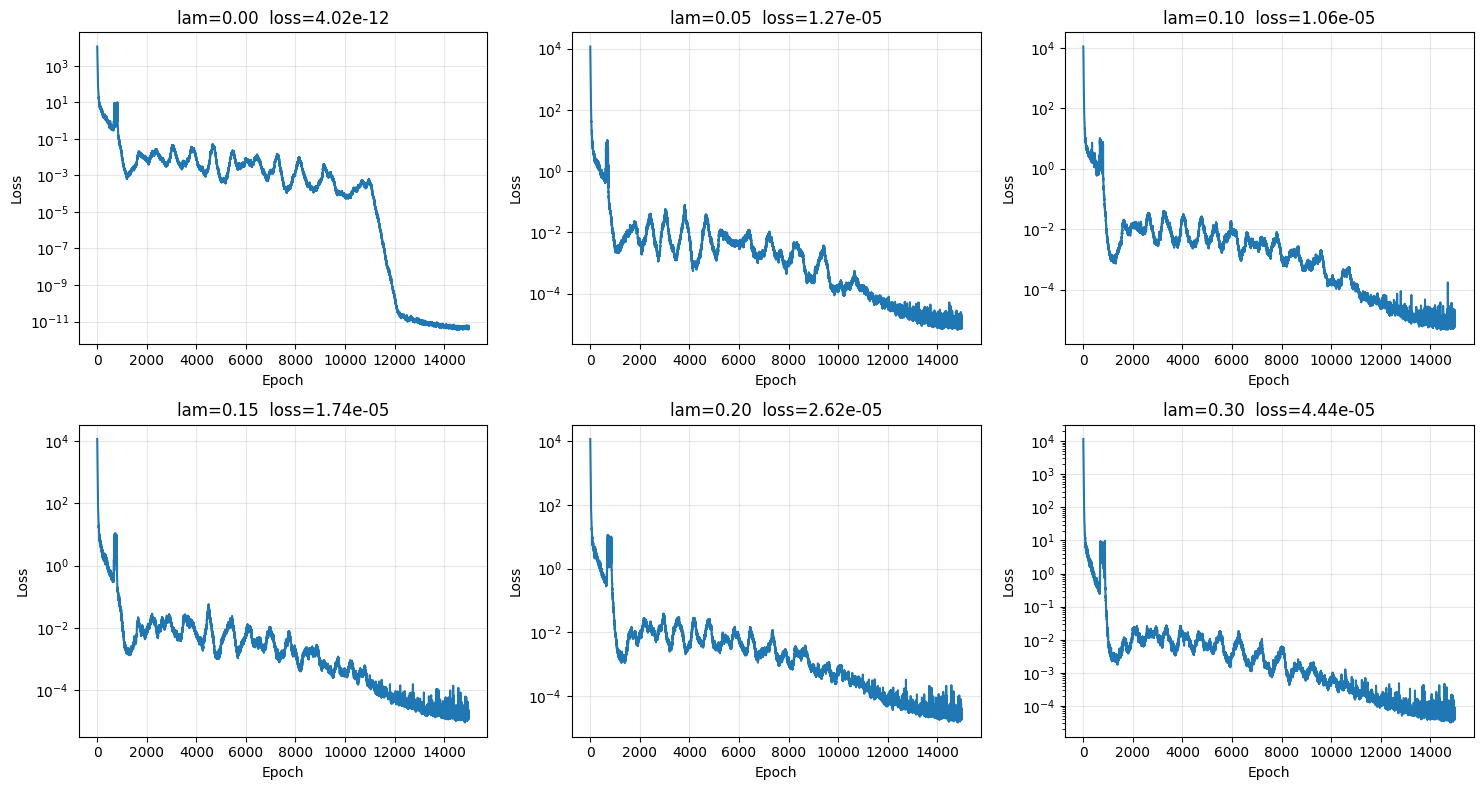

Saved loss_curves_page1.png


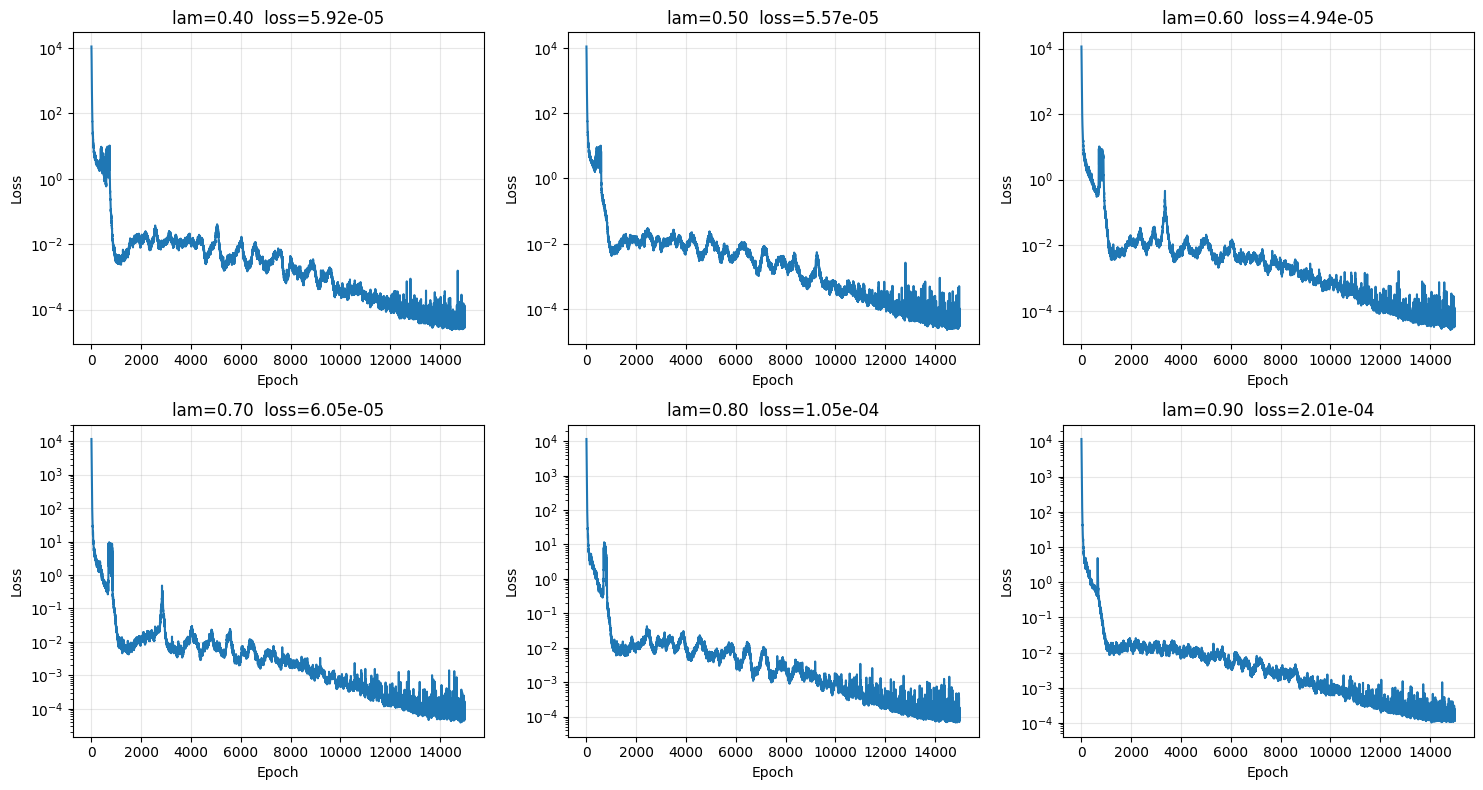

Saved loss_curves_page2.png


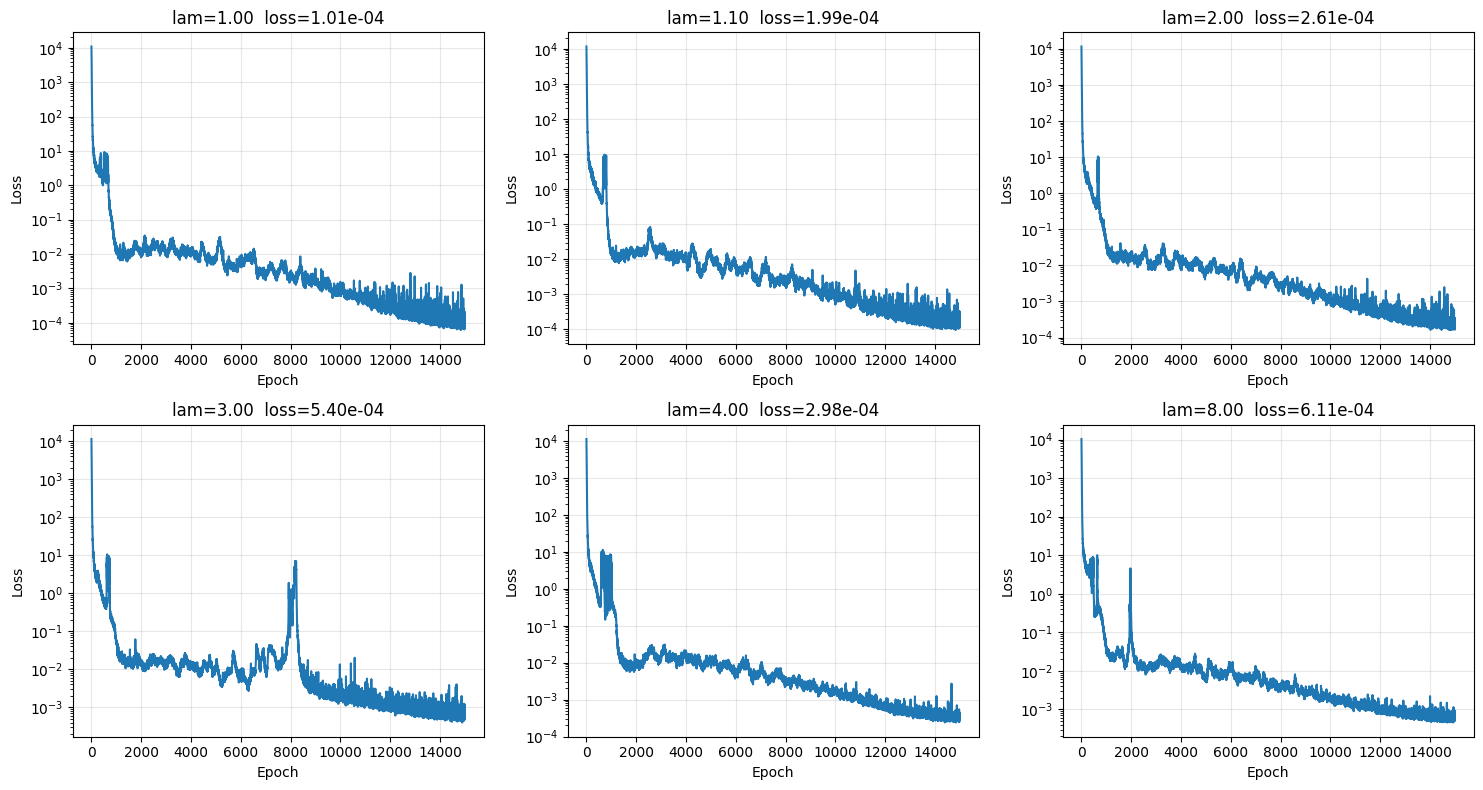

Saved loss_curves_page3.png


In [9]:
n_per_page = 6
n_pages = math.ceil(len(scan_results) / n_per_page)
for pg in range(n_pages):
    subset = scan_results[pg*n_per_page : (pg+1)*n_per_page]
    nrows = math.ceil(len(subset) / 3)
    ncols = min(len(subset), 3)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for idx, r in enumerate(subset):
        row, col = divmod(idx, 3)
        ax = axes[row][col]
        ax.semilogy(r['loss_history'])
        ax.set_title(f"lam={r['lam']:.2f}  loss={r['final_loss']:.2e}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
    for idx in range(len(subset), nrows*ncols):
        row, col = divmod(idx, 3)
        axes[row][col].set_visible(False)
    plt.tight_layout()
    fig.savefig(f"loss_curves_page{pg+1}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved loss_curves_page{pg+1}.png")

### Arrow diagrams — AFTER training (6 per page)

Shows learned-thimble importance-weight arrows for each $\lambda$.

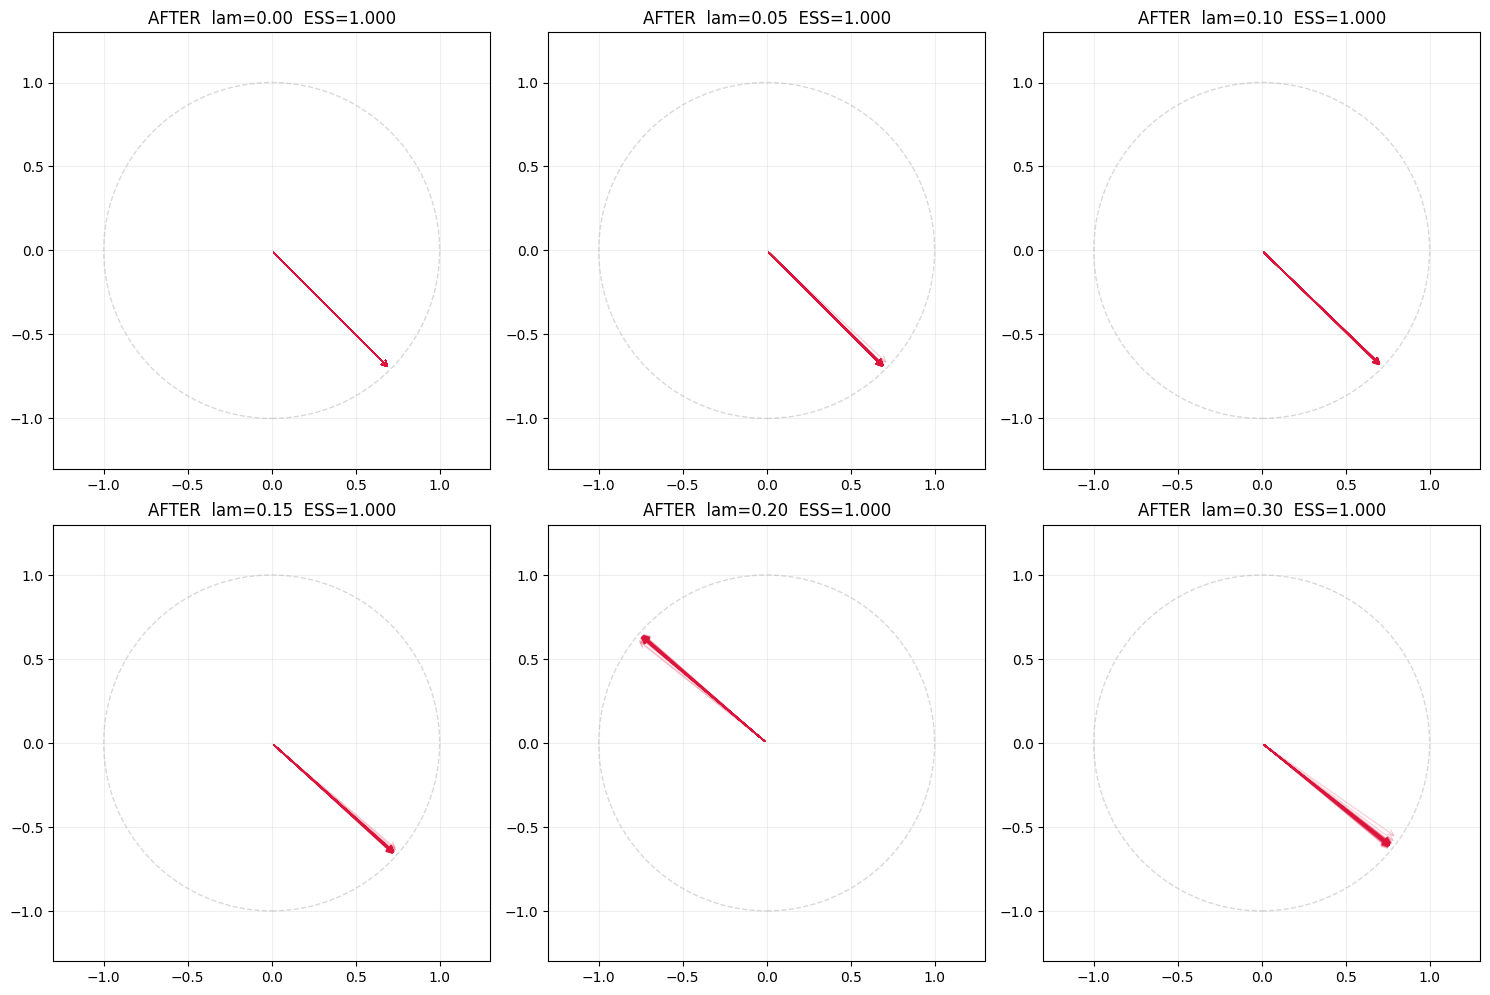

Saved arrows_after_page1.png


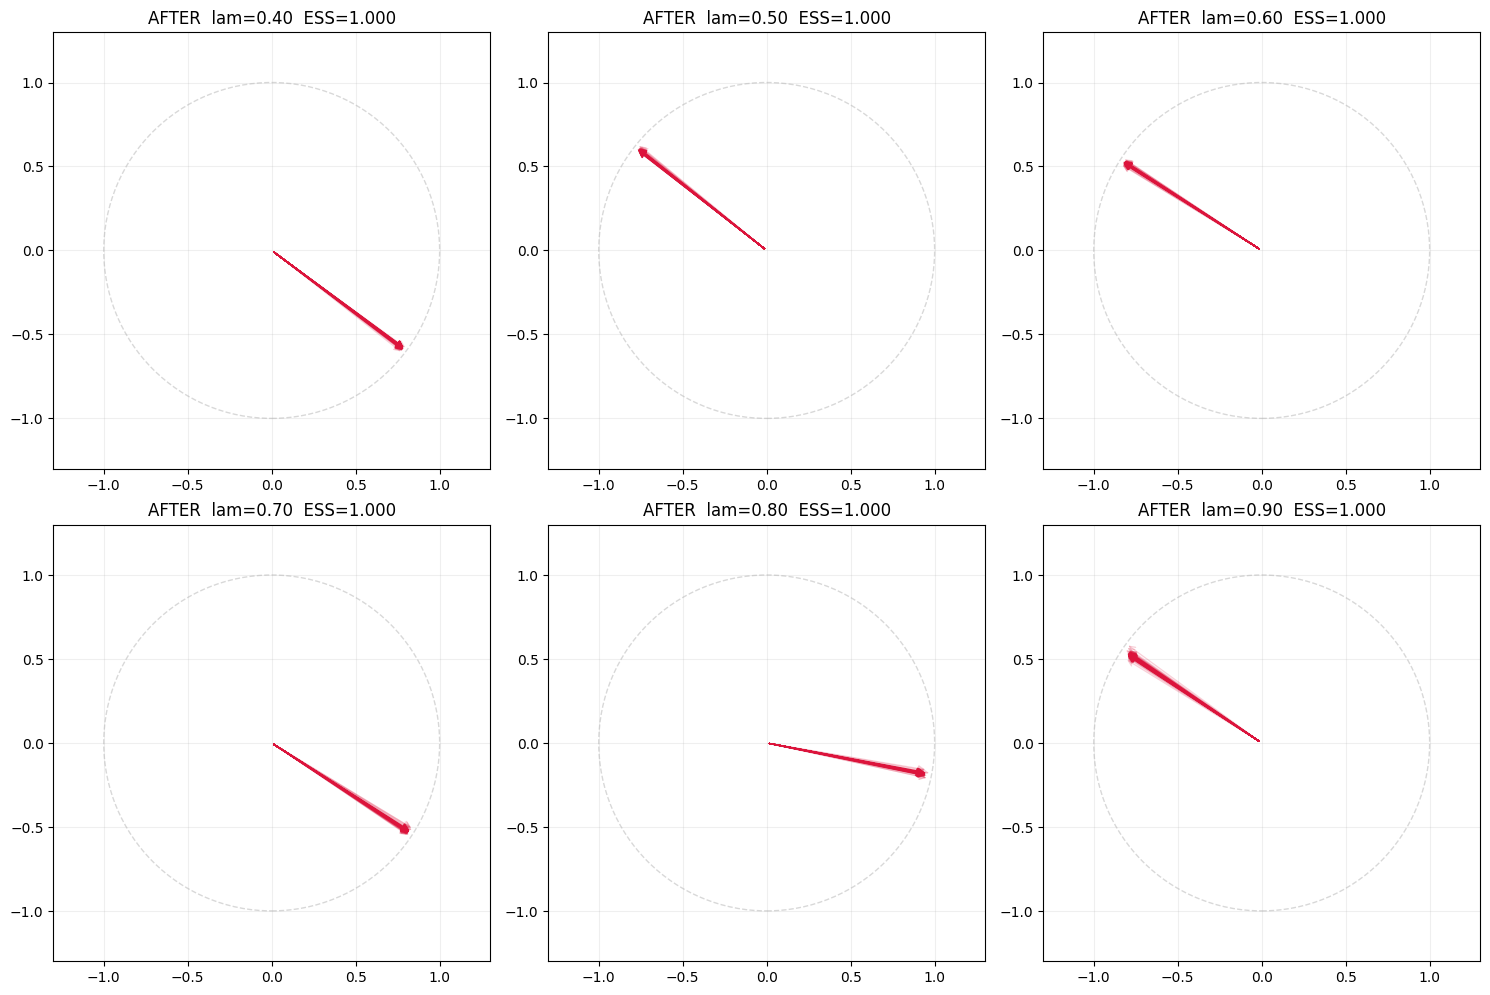

Saved arrows_after_page2.png


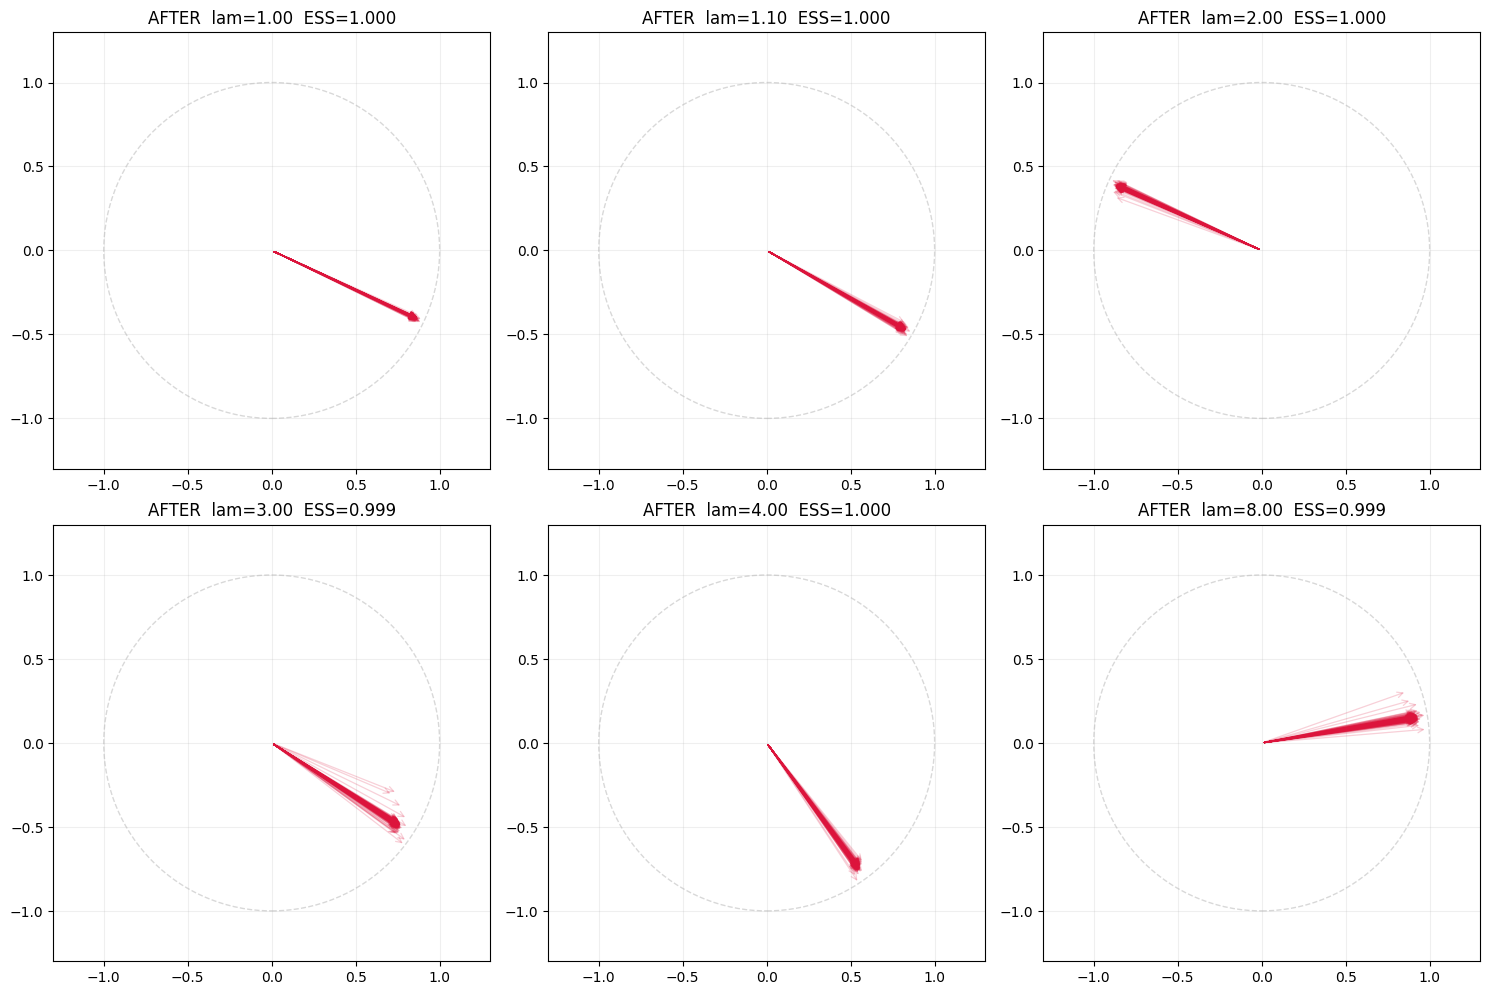

Saved arrows_after_page3.png


In [10]:
for pg in range(n_pages):
    subset = scan_results[pg*n_per_page : (pg+1)*n_per_page]
    nrows = math.ceil(len(subset) / 3)
    ncols = min(len(subset), 3)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), squeeze=False)
    for idx, r in enumerate(subset):
        row, col = divmod(idx, 3)
        ax = axes[row][col]
        W = r['W_after_norm']
        for i in range(len(W)):
            ax.annotate('', xy=(W[i].real, W[i].imag), xytext=(0,0),
                        arrowprops=dict(arrowstyle='->', color='crimson', alpha=0.2, lw=0.9))
        ax.add_patch(plt.Circle((0,0), 1, fill=False, color='gray', ls='--', alpha=0.3))
        ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
        ax.set_aspect('equal')
        ax.set_title(f"AFTER  lam={r['lam']:.2f}  ESS={r['ess_n']:.3f}")
        ax.grid(True, alpha=0.2)
    for idx in range(len(subset), nrows*ncols):
        row, col = divmod(idx, 3)
        axes[row][col].set_visible(False)
    plt.tight_layout()
    fig.savefig(f"arrows_after_page{pg+1}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved arrows_after_page{pg+1}.png")

## 7. Sanity Check: $\lambda=0$ — ML vs Basis Truncation vs Mehler

All three methods should agree at $\lambda=0$ for $(0, 0)$ endpoints.

In [11]:
print("=" * 70)
print("SANITY CHECK: lam=0, (0,0) — ML vs Basis vs Mehler")
print("=" * 70)

r0 = [r for r in scan_results if abs(r['lam']) < 1e-12]
if r0:
    r0 = r0[0]
    K_ml  = r0['K_re'] + 1j * r0['K_im']
    K_bas = r0['K_basis_re'] + 1j * r0['K_basis_im']
    K_meh = mehler_kernel(0, 0, T, m, omega)

    err_ml_meh  = abs(K_ml  - K_meh) / abs(K_meh)
    err_bas_meh = abs(K_bas - K_meh) / abs(K_meh)
    err_ml_bas  = abs(K_ml  - K_bas) / abs(K_bas)

    print(f"  Mehler (exact):     {K_meh:.10f}")
    print(f"  ML NN thimble:     {K_ml:.10f}   rel err vs Mehler: {err_ml_meh:.4e}")
    print(f"  Basis truncation:  {K_bas:.10f}   rel err vs Mehler: {err_bas_meh:.4e}")
    print(f"  ML vs Basis:       rel diff = {err_ml_bas:.4e}")
    print()
    all_pass = err_ml_meh < 0.02 and err_bas_meh < 0.01 and err_ml_bas < 0.02
    print(f"  >> {'ALL THREE AGREE — PASSED' if all_pass else 'DISCREPANCY — CHECK'}")
else:
    print("  lam=0 not in scan! Add 0.0 to lambda_list.")

SANITY CHECK: lam=0, (0,0) — ML vs Basis vs Mehler
  Mehler (exact):     0.4183666762-0.4183666762j
  ML NN thimble:     0.4177583530-0.4184572818j   rel err vs Mehler: 1.0395e-03
  Basis truncation:  0.4183640411-0.4183668729j   rel err vs Mehler: 4.4661e-06
  ML vs Basis:       rel diff = 1.0351e-03

  >> ALL THREE AGREE — PASSED


### Sanity check: $\lambda = 0.05$ — ML vs Basis should be very close

In [12]:
r005 = [r for r in scan_results if abs(r['lam'] - 0.05) < 1e-6]
if r005:
    r005 = r005[0]
    K_ml  = r005['K_re'] + 1j * r005['K_im']
    K_bas = r005['K_basis_re'] + 1j * r005['K_basis_im']
    rel = abs(K_ml - K_bas) / abs(K_bas)
    print(f"lam=0.05 sanity:")
    print(f"  ML:    {K_ml:.10f}")
    print(f"  Basis: {K_bas:.10f}")
    print(f"  rel diff: {rel:.4e}  >> {'PASSED' if rel < 0.05 else 'CHECK'}")
else:
    print("  lam=0.05 not in scan!")

lam=0.05 sanity:
  ML:    0.4196368190-0.4169231080j
  Basis: 0.4194760264-0.4172209620j
  rel diff: 5.7211e-04  >> PASSED


## 8. Physics Checks (for non-zero endpoints — NOT RUN)

The cells below are **kept for future use** when testing non-zero endpoints.
They are wrapped in `if False:` so they do not execute in this notebook.

In [13]:
if False:
    # ── Large endpoint suppression ──
    res_near = run_single(0.2, x_i=0, x_f=0, N_val=N, T_val=T, m_val=m,
                          omega_val=omega, eps_val=epsilon, rank_val=rank,
                          epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    res_far  = run_single(0.2, x_i=0, x_f=5.0, N_val=N, T_val=T, m_val=m,
                          omega_val=omega, eps_val=epsilon, rank_val=rank,
                          epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    ratio = res_far['abs_K'] / res_near['abs_K']
    print(f"|K(5)|/|K(0)| = {ratio:.4f}  >> {'PASSED' if ratio < 0.5 else 'FAILED'}")

if False:
    # ── Strong coupling squeeze ──
    res_lam0_o = run_single(0.0, x_i=0, x_f=0, N_val=N, T_val=T, m_val=m,
                            omega_val=omega, eps_val=epsilon, rank_val=rank,
                            epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    res_lam2_o = run_single(2.0, x_i=0, x_f=0, N_val=N, T_val=T, m_val=m,
                            omega_val=omega, eps_val=epsilon, rank_val=rank,
                            epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    res_lam0_f = run_single(0.0, x_i=0, x_f=3.0, N_val=N, T_val=T, m_val=m,
                            omega_val=omega, eps_val=epsilon, rank_val=rank,
                            epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    res_lam2_f = run_single(2.0, x_i=0, x_f=3.0, N_val=N, T_val=T, m_val=m,
                            omega_val=omega, eps_val=epsilon, rank_val=rank,
                            epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    origin_up = res_lam2_o['abs_K'] > res_lam0_o['abs_K']
    far_down  = res_lam2_f['abs_K'] < res_lam0_f['abs_K']
    print(f"Origin: {'UP' if origin_up else 'DOWN'}  Far: {'DOWN' if far_down else 'UP'}")

if False:
    # ── Free particle limit ──
    res_free = run_single(0.0, x_i=0, x_f=0, N_val=N, T_val=T, m_val=m,
                          omega_val=0.0, eps_val=epsilon, rank_val=rank,
                          epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    K_free_exact = free_particle_kernel(0, 0, T, m)
    K_ml = res_free['K_re'] + 1j * res_free['K_im']
    rel = abs(K_ml - K_free_exact) / abs(K_free_exact)
    print(f"Free particle: rel err = {rel:.4e}  >> {'PASSED' if rel < 0.02 else 'FAILED'}")

if False:
    # ── Short time limit ──
    res_short = run_single(2.0, x_i=0, x_f=0, N_val=N, T_val=0.01, m_val=m,
                           omega_val=omega, eps_val=epsilon, rank_val=rank,
                           epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    K_free_short = free_particle_kernel(0, 0, 0.01, m)
    K_ml = res_short['K_re'] + 1j * res_short['K_im']
    rel = abs(K_ml - K_free_short) / abs(K_free_short)
    print(f"Short time: rel err = {rel:.4e}  >> {'PASSED' if rel < 0.05 else 'FAILED'}")

## 9. Comparison Plot: ML Best Seed vs Basis Truncation

For each $\lambda$, plots the propagator components ($\mathrm{Re}\,K$, $\mathrm{Im}\,K$, $|K|$)
from the **best-seed ML run** alongside the **basis truncation** estimate.

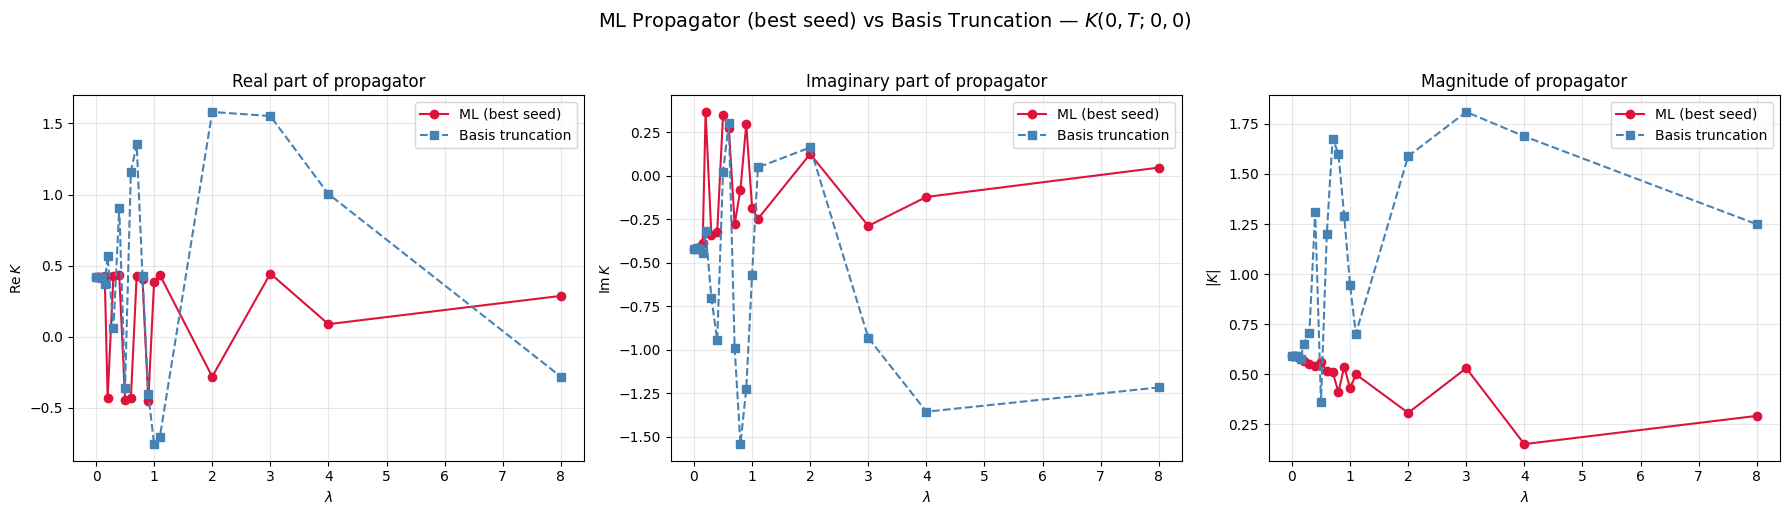

Saved ml_vs_basis_comparison.png


In [14]:
lams_best     = np.array([r['lam']        for r in best_results])
ml_re_best    = np.array([r['K_re']       for r in best_results])
ml_im_best    = np.array([r['K_im']       for r in best_results])
ml_abs_best   = np.array([r['abs_K']      for r in best_results])
basis_re      = np.array([r['K_basis_re'] for r in best_results])
basis_im      = np.array([r['K_basis_im'] for r in best_results])
basis_abs     = np.array([r['abs_K_basis'] for r in best_results])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Re(K) ──
ax = axes[0]
ax.plot(lams_best, ml_re_best,  'o-', color='crimson',   label='ML (best seed)')
ax.plot(lams_best, basis_re,    's--', color='steelblue', label='Basis truncation')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\mathrm{Re}\,K$')
ax.set_title(r'Real part of propagator')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Im(K) ──
ax = axes[1]
ax.plot(lams_best, ml_im_best,  'o-', color='crimson',   label='ML (best seed)')
ax.plot(lams_best, basis_im,    's--', color='steelblue', label='Basis truncation')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\mathrm{Im}\,K$')
ax.set_title(r'Imaginary part of propagator')
ax.legend()
ax.grid(True, alpha=0.3)

# ── |K| ──
ax = axes[2]
ax.plot(lams_best, ml_abs_best,  'o-', color='crimson',   label='ML (best seed)')
ax.plot(lams_best, basis_abs,    's--', color='steelblue', label='Basis truncation')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$|K|$')
ax.set_title(r'Magnitude of propagator')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(r'ML Propagator (best seed) vs Basis Truncation — $K(0,T;0,0)$',
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig("ml_vs_basis_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved ml_vs_basis_comparison.png")